In [ ]:
!pip install yfinance pandas numpy matplotlib seaborn scipy

In [ ]:
#QUESTION 1: BASIC STATISTICAL CALCULATIONS
import numpy as np

#import the array
x2 = [0.26, 0.43, 0.47, 0.49, 0.52, 0.75, 0.79, 0.86, 0.62, 0.46]

#calculate the mean
mean_x2 = np.mean(x2)
print(f"The mean of x2: {mean_x2}")

#sort the array
x2_sorted = sorted(x2)

#calculate the 10% trimmed mean
n1 = int(len(x2_sorted) * 0.1)
trimmed_x2_10 = x2_sorted[n1:-n1]
x2_trimmed_mean10 = np.mean(trimmed_x2_10)
print(f"The 10% trimmed mean of x2: {x2_trimmed_mean10}")

#calcualte the 5% trimmed mean
n2 = max(1, int(len(x2_sorted) * 0.05))
trimmed_x2_5 = x2_sorted[n2:-n2]
trimmed_x2_5 = x2_sorted[n2:-n2]
x2_trimmed_mean5 = np.mean(trimmed_x2_5)
print(f"The 5% trimmed mean of x2: {x2_trimmed_mean5}")

#find the Winsorized version of the array with 5% limits on both ends
n = int(len(x2_sorted) * 0.05)
lower_bound = x2_sorted[n]
upper_bound = x2_sorted[-n-1]
winsorized_x2= np.clip(x2_sorted, lower_bound, upper_bound)
print(f"The Winsorized version of x2 with 5% limits on both ends: {winsorized_x2}")

#find the mean of the Winsorized version of the array
mean_winsorized_x2 = np.mean(winsorized_x2)
print(f"The mean of the Winsorized x2 with 5% limits on both ends: {mean_winsorized_x2}")

The mean of x2: 0.5650000000000001
The 10% trimmed mean of x2: 0.56625
The 5% trimmed mean of x2: 0.56625
The Winsorized version of x2 with 5% limits on both ends: [0.26 0.43 0.46 0.47 0.49 0.52 0.62 0.75 0.79 0.86]
The mean of the Winsorized x2 with 5% limits on both ends: 0.5650000000000001


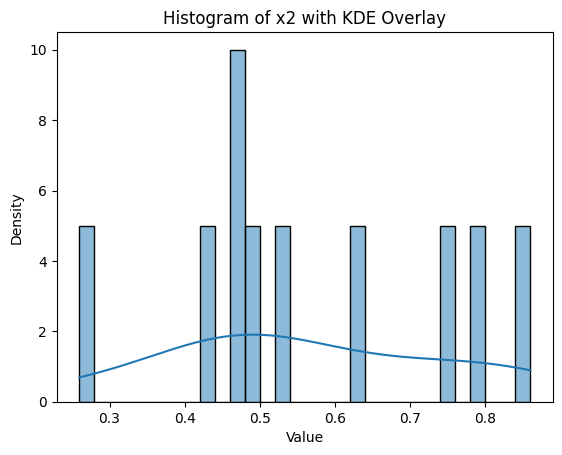

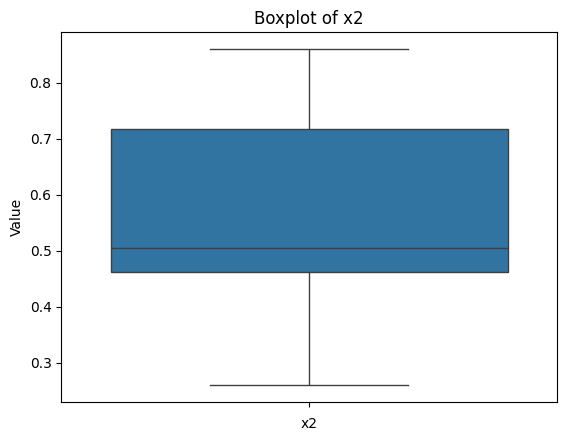

95% Confidence Interval for the Mean: (0.46, 0.68)
95% Confidence Interval for the Mean: (0.46, 0.68)


In [ ]:
#QUESTION 2: DATA VISUALIZATION AND BOOTSTRAPPING
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Plot a histogram of x2 with a kernel density estimate (KDE) overlay
x2 = [0.26, 0.43, 0.47, 0.49, 0.52, 0.75, 0.79, 0.86, 0.62, 0.46]
sns.histplot(x2, bins=30, kde=True, stat="density", edgecolor="black", alpha=0.5)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram of x2 with KDE Overlay")
plt.show()

#Create a boxplot of x2
sns.boxplot(data=x2)
plt.xlabel("x2")
plt.ylabel("Value")
plt.title("Boxplot of x2")
plt.show()

#Perform bootstrapping by generating 1000 resamples of x2 and calculate the mean of each resample

def bootstrap(data, num_samples = 1000, statistic=np.mean):
  bootstrapped_stats = np.empty(num_samples)

  for i in range(num_samples):
    resample = np.random.choice(data, size = len(data), replace=True)
    bootstrapped_stats[i] = statistic(resample)

  return bootstrapped_stats

bootstrap_means_x2 = bootstrap(x2)

#Compute the 95% confidence interval for the mean using the percentile method
lower_bound = np.percentile(bootstrap_means_x2, 2.5)
upper_bound = np.percentile(bootstrap_means_x2, 97.5)
print(f"95% Confidence Interval for the Mean: ({lower_bound:.2f}, {upper_bound:.2f})")

#Compute the 95% confidence interval for the mean using the standard error method
std_error = np.std(bootstrap_means_x2, ddof=1)
mean_estimate = np.mean(bootstrap_means_x2)
lower_bound_se = mean_estimate - 1.96 * std_error
upper_bound_se = mean_estimate + 1.96 * std_error
print(f"95% Confidence Interval for the Mean: ({lower_bound_se:.2f}, {upper_bound_se:.2f})")


#Print the lower and upper bounds for both methods


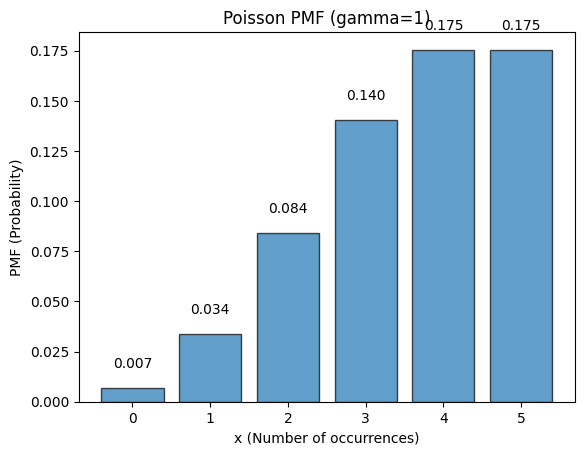

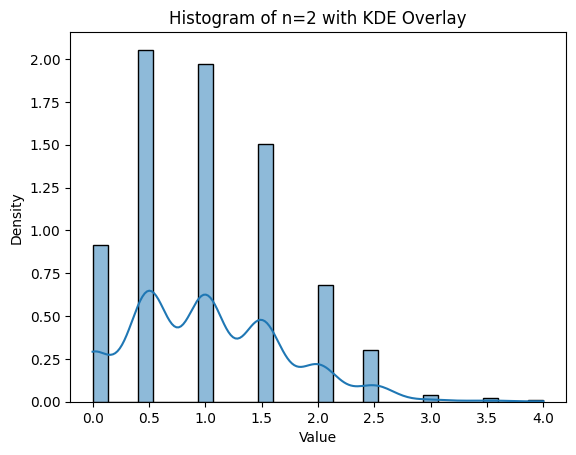

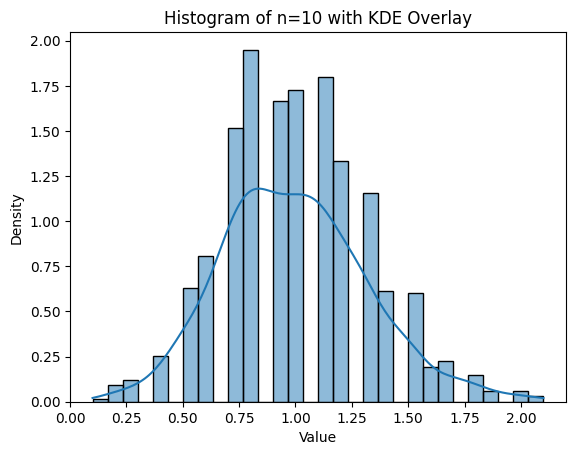

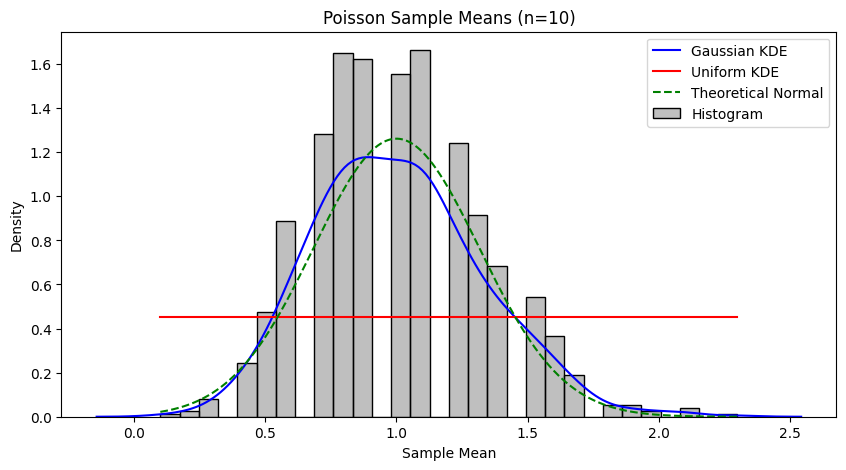

In [ ]:
#QUESTION 3: POISSON DISTRIBUTION AND SAMPLING

from scipy.stats import poisson, gaussian_kde, uniform, norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#For a Poisson distribution with `gamma = 1`, calculate the probability mass function (PMF) for x = 0 to 5 and plot a bar chart of the probabilities
gamma = 5
x_values = np.arange(6)
pmf_values = poisson.pmf(x_values, gamma)

plt.bar(x_values, pmf_values, alpha=0.7, edgecolor='black')
plt.xlabel("x (Number of occurrences)")
plt.ylabel("PMF (Probability)")
plt.title("Poisson PMF (gamma=1)")
for i, v in enumerate(pmf_values):
    plt.text(x_values[i], v + 0.01, f"{v:.3f}", ha='center')
plt.show()

#Write a function `meanpoisson(n)` that generates 1000 samples of size `n` from a Poisson distribution with `gamma = 1` and returns the sample means.

def meanpoisson(n, gamma=1, num_samples=1000):
  samples = np.random.poisson(gamma, (num_samples, n))
  sample_means = np.mean(samples, axis=1)
  return sample_means

#Plot histograms of the sample means for `n = 2` and `n = 10`, each with a KDE overlay.
sns.histplot(meanpoisson(2), bins=30, kde=True, stat="density", edgecolor="black", alpha=0.5)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram of n=2 with KDE Overlay")
plt.show()

sns.histplot(meanpoisson(10), bins=30, kde=True, stat="density", edgecolor="black", alpha=0.5)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram of n=10 with KDE Overlay")
plt.show()

# Overlay a Gaussian (normal) KDE and a rectangular (uniform) KDE on the histogram for `n= 10'
sample_means = meanpoisson(10)
x_vals = np.linspace(min(sample_means), max(sample_means), 1000)
gaussian_kde_est = gaussian_kde(sample_means)
uniform_kde_est = uniform.pdf(x_vals, loc=min(sample_means), scale=max(sample_means) - min(sample_means))
theoretical_mean = 1
theoretical_std = 1 / np.sqrt(10)
normal_pdf = norm.pdf(x_vals, loc=theoretical_mean, scale=theoretical_std)

plt.figure(figsize=(10, 5))
sns.histplot(sample_means, bins=30, kde=False, stat="density", alpha=0.5, color="gray", label="Histogram")
sns.kdeplot(sample_means, bw_adjust=1, label="Gaussian KDE", color="blue")
plt.plot(x_vals, uniform_kde_est, label="Uniform KDE", color="red")
plt.plot(x_vals, normal_pdf, label="Theoretical Normal", color="green", linestyle="dashed")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.title("Poisson Sample Means (n=10)")
plt.legend()
plt.show()


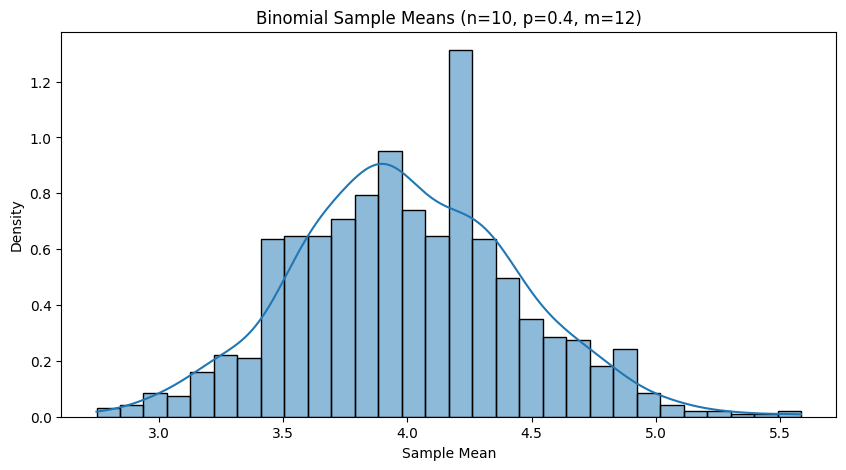

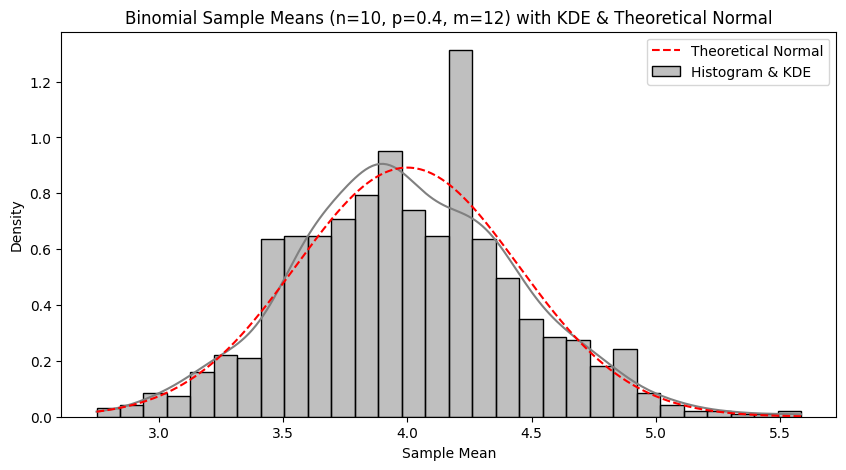

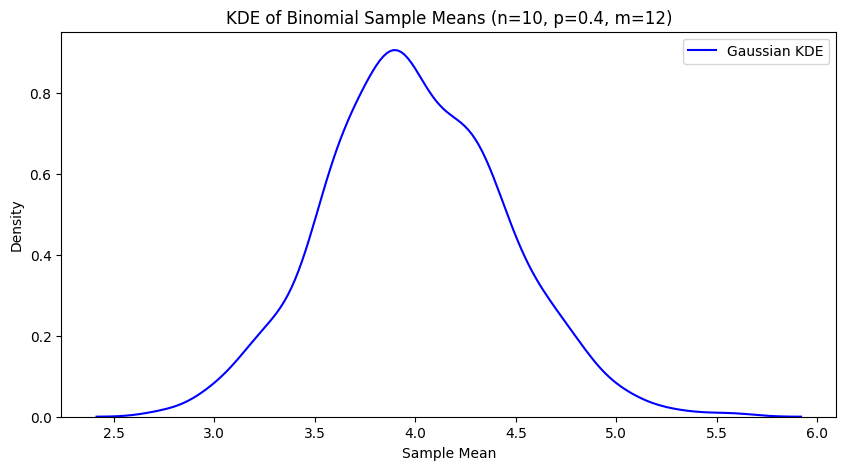

In [ ]:
#QUESTION 4: BINOMIAL DISTRIBUTION AND SAMPLING

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

def meanpoisson(n, gamma=1, num_samples=1000):
    samples = np.random.poisson(gamma, (num_samples, n))
    sample_means = np.mean(samples, axis=1)
    return sample_means

#For a Binomial distribution with `n = 10` trials and success probability `p = 0.4`, generate 1000 samples of size `m = 12` and calculate the sample means
n_binomial = 10
p_binomial = 0.4
m = 12
num_samples = 1000

binomial_samples = np.random.binomial(n_binomial, p_binomial, (num_samples, m))
binomial_sample_means = np.mean(binomial_samples, axis=1)
df_binomial_means = pd.DataFrame({'Sample Mean': binomial_sample_means})

#Plot a histogram of the sample means with a KDE overlay.
plt.figure(figsize=(10, 5))
sns.histplot(binomial_sample_means, bins=30, kde=True, stat="density", edgecolor="black", alpha=0.5)
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.title("Binomial Sample Means (n=10, p=0.4, m=12)")
plt.show()

#Overlay the theoretical normal distribution with mean `m * p` and standard deviation `√(m * p * (1 - p) / n)` on the same graph
theoretical_mean_binomial = n_binomial * p_binomial
theoretical_std_binomial = np.sqrt((n_binomial * p_binomial * (1 - p_binomial)) / m)

x_vals_binomial = np.linspace(min(binomial_sample_means), max(binomial_sample_means), 1000)
normal_pdf_binomial = norm.pdf(x_vals_binomial, loc=theoretical_mean_binomial, scale=theoretical_std_binomial)

plt.figure(figsize=(10, 5))
sns.histplot(binomial_sample_means, bins=30, kde=True, stat="density", edgecolor="black", alpha=0.5, color="gray", label="Histogram & KDE")
plt.plot(x_vals_binomial, normal_pdf_binomial, label="Theoretical Normal", color="red", linestyle="dashed")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.title("Binomial Sample Means (n=10, p=0.4, m=12) with KDE & Theoretical Normal")
plt.legend()
plt.show()

#Plot a KDE of the sample means
plt.figure(figsize=(10, 5))
sns.kdeplot(binomial_sample_means, bw_adjust=1, label="Gaussian KDE", color="blue")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.title("KDE of Binomial Sample Means (n=10, p=0.4, m=12)")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

symbols = ["^GSPC", "QQQ", "TSLA", "AMZN"]
start_date = "2022-01-03"
end_date = "2024-12-31"
data = yf.download(symbols, start=start_date, end=end_date, progress=False)['Close']
returns = data.pct_change().dropna()

#Which one is the most volatile in its return?
volatility = returns.std()
most_volatile_stock = volatility.idxmax()

#If you are going to invest between SP500 and QQQ, what is the proportion in SP500 to minimize the total risk?
cov_matrix = returns.cov()

#If you are going to invest between Tesla and Amazon, what is the proportion in Tesla to minimize the total risk? What is the standard error of the proportion? What is correlation and the standard error of the correlation of the two returns?

w_opt_sp500_qqq = np.linalg.solve(cov_matrix.loc[["^GSPC", "QQQ"], ["^GSPC", "QQQ"]], np.array([1, 1]))
w_opt_sp500_qqq /= np.sum(w_opt_sp500_qqq)
w_opt_tesla_amazon = np.linalg.solve(cov_matrix.loc[["TSLA", "AMZN"], ["TSLA", "AMZN"]], np.array([1, 1]))
w_opt_tesla_amazon /= np.sum(w_opt_tesla_amazon)
correlation_tesla_amazon = returns["TSLA"].corr(returns["AMZN"])
n_obs = len(returns)
std_error_correlation = np.sqrt((1 - correlation_tesla_amazon ** 2) / (n_obs - 2))
std_error_tesla_prop = np.sqrt((w_opt_tesla_amazon[0] * (1 - w_opt_tesla_amazon[0])) / n_obs)

results = {
    "Most Volatile Stock": most_volatile_stock,
    "Proportion in SP500 to Minimize Risk": w_opt_sp500_qqq[0],
    "Proportion in QQQ to Minimize Risk": w_opt_sp500_qqq[1],
    "Proportion in Tesla to Minimize Risk": w_opt_tesla_amazon[0],
    "Proportion in Amazon to Minimize Risk": w_opt_tesla_amazon[1],
    "Standard Error of Tesla Proportion": std_error_tesla_prop,
    "Correlation (Tesla, Amazon)": correlation_tesla_amazon,
    "Standard Error of Correlation": std_error_correlation,
}

print(results)

ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['TSLA', '^GSPC', 'AMZN', 'QQQ']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


{'Most Volatile Stock': nan, 'Proportion in SP500 to Minimize Risk': nan, 'Proportion in QQQ to Minimize Risk': nan, 'Proportion in Tesla to Minimize Risk': nan, 'Proportion in Amazon to Minimize Risk': nan, 'Standard Error of Tesla Proportion': nan, 'Correlation (Tesla, Amazon)': nan, 'Standard Error of Correlation': nan}


<ipython-input-11-8b8460244e8c>:14: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  most_volatile_stock = volatility.idxmax()
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.11/dist-packages/pandas/core/frame.py:11211: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
